In [1]:
# Run this cell once to install all required libraries.
# In VS Code: you can also run `pip install ...` in the terminal instead.
pip install datasets pandas numpy matplotlib seaborn plotly --quiet

SyntaxError: invalid syntax (2591967659.py, line 3)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datasets import load_dataset

# Makes plots look nicer
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

c:\Users\Sreeansh Dash\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1 — Load the NidaanKosha Dataset
The dataset is hosted on HuggingFace. `load_dataset` downloads and caches it automatically.  
First load will take a few minutes (~176 MB). Subsequent runs use the local cache.

In [3]:
# This downloads the dataset from HuggingFace and converts it to a pandas DataFrame.
# The dataset is in LONG format: one row per test per patient.
ds = load_dataset("ekacare/NidaanKosha-100k-V1.0")
df = ds["train"].to_pandas()

print(f"Shape: {df.shape}")          # (rows, columns)
print(f"Columns: {df.columns.tolist()}")
df.head(10)

c:\Users\Sreeansh Dash\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Sreeansh Dash\.cache\huggingface\hub\datasets--ekacare--NidaanKosha-100k-V1.0. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is 

Shape: (6844304, 9)
Columns: ['document_id', 'age', 'gender', 'test_name', 'display_ranges', 'value', 'unit', 'specimen', 'loinc']


,document_id,age,gender,test_name,display_ranges,value,unit,specimen,loinc
0,a1ce7f03fca11a7351927f5d6d635552,72,female,% TRANSFERRIN SATURATION,None,25.4100,%,blood,2502-3
1,a1ce7f03fca11a7351927f5d6d635552,72,female,IRON,None,98.6000,ug/dl,None,2498-4
2,a1ce7f03fca11a7351927f5d6d635552,72,female,TOTAL IRON BINDING CAPACITY (TIBC),None,388.0000,ug/dl,blood,2500-7
3,a1ce7f03fca11a7351927f5d6d635552,72,female,ALANINE TRANSAMINASE (SGPT),< 34.0,29.4600,U/I,blood,1742-6
4,a1ce7f03fca11a7351927f5d6d635552,72,female,ALBUMIN SERUM,3.2 - 4.8,4.4400,gm/dl,blood,1751-7
5,a1ce7f03fca11a7351927f5d6d635552,72,female,ALKALINE PHOSPHATASE,45.0 - 129.0,63.8300,U/L,blood,6768-6
6,a1ce7f03fca11a7351927f5d6d635552,72,female,ASPARTATE AMINOTRANSFERASE (SGOT ),< 31.0,26.9200,U/I,blood,1920-8
7,a1ce7f03fca11a7351927f5d6d635552,72,female,BILIRUBIN (INDIRECT),0.0 - 0.9,0.4800,mg/dl,blood,1971-1
8,a1ce7f03fca11a7351927f5d6d635552,72,female,BILIRUBIN -DIRECT,< 0.3,0.2100,mg/dl,blood,1968-7
9,a1ce7f03fca11a7351927f5d6d635552,72,female,BILIRUBIN TOTAL,0.3 - 1.2,0.6900,mg/dl,blood,1975-2


## Step 2 — Basic Exploration
Before any analysis, we check data types, nulls, and unique value counts.

In [4]:
# dtypes and non-null counts per column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6844304 entries, 0 to 6844303
Data columns (total 9 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   document_id     object
 1   age             int64 
 2   gender          object
 3   test_name       object
 4   display_ranges  object
 5   value           object
 6   unit            object
 7   specimen        object
 8   loinc           object
dtypes: int64(1), object(8)
memory usage: 470.0+ MB


In [5]:
# How many unique patients, tests, and LOINC codes are there?
print(f"Unique patients   : {df['document_id'].nunique():,}")
print(f"Total test rows   : {len(df):,}")
print(f"Unique test names : {df['test_name'].nunique():,}")
print(f"Unique LOINC codes: {df['loinc'].nunique():,}")
print(f"Specimen types    : {df['specimen'].unique()}")

Unique patients   : 100,000
Total test rows   : 6,844,304
Unique test names : 64,327
Unique LOINC codes: 581
Specimen types    : ['blood' None 'urine' 'stool' 'semen' 'pus' 'respiratory' 'patient'
 'body_fluid' 'tissue' 'urine_24h' 'eye_swab' 'ear_swab']


In [6]:
# Missing values — what % of each column is null?
missing = df.isnull().mean() * 100
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing value % per column:")
print(missing.round(2))

Missing value % per column:
unit              14.78
display_ranges    10.87
loinc              7.24
specimen           5.85
test_name          0.00
dtype: float64


## Step 3 — Age & Gender Distributions
Since this is a per-test long format, each patient appears multiple times.  
We deduplicate to get one row per patient before plotting demographics.

In [7]:
# One row per patient (keep first occurrence)
patients = df.drop_duplicates(subset="document_id")[["document_id", "age", "gender"]].copy()

print(f"Patient count : {len(patients):,}")
print(f"Age range     : {patients['age'].min()} – {patients['age'].max()}")
print(f"Gender counts :\n{patients['gender'].value_counts()}")

Patient count : 100,000
Age range     : 17 – 105
Gender counts :
gender
male      57346
female    42654
Name: count, dtype: int64


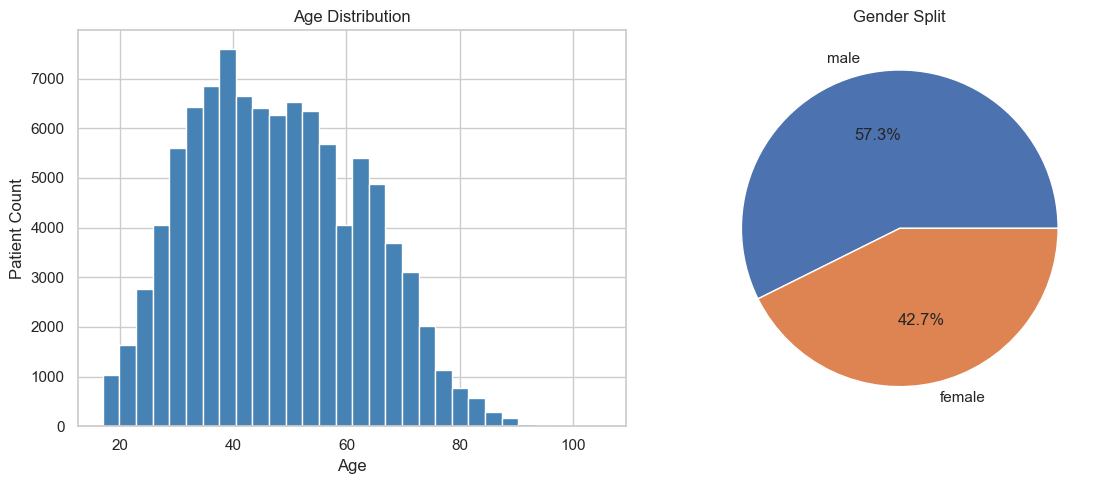

In [8]:
fig, axes = plt.subplots(1, 2)

# Age histogram
axes[0].hist(patients["age"].dropna(), bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Patient Count")

# Gender pie chart
gender_counts = patients["gender"].value_counts()
axes[1].pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%",
            colors=["#4C72B0", "#DD8452"])
axes[1].set_title("Gender Split")

plt.tight_layout()
plt.show()

## Step 4 — Test Coverage Per Patient
Not every patient has every test. This tells us how sparse the data will be  
after we pivot to wide format (one row per patient, one column per test).

Avg tests per patient : 67.9
Min tests per patient : 17
Max tests per patient : 194


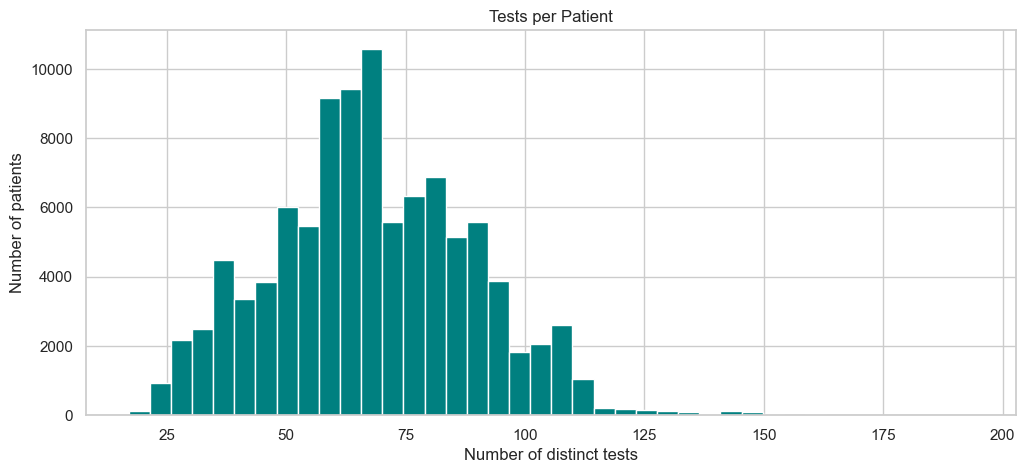

In [9]:
# Count how many distinct tests each patient has
tests_per_patient = df.groupby("document_id")["test_name"].nunique()

print(f"Avg tests per patient : {tests_per_patient.mean():.1f}")
print(f"Min tests per patient : {tests_per_patient.min()}")
print(f"Max tests per patient : {tests_per_patient.max()}")

plt.figure()
tests_per_patient.hist(bins=40, color="teal", edgecolor="white")
plt.title("Tests per Patient")
plt.xlabel("Number of distinct tests")
plt.ylabel("Number of patients")
plt.show()

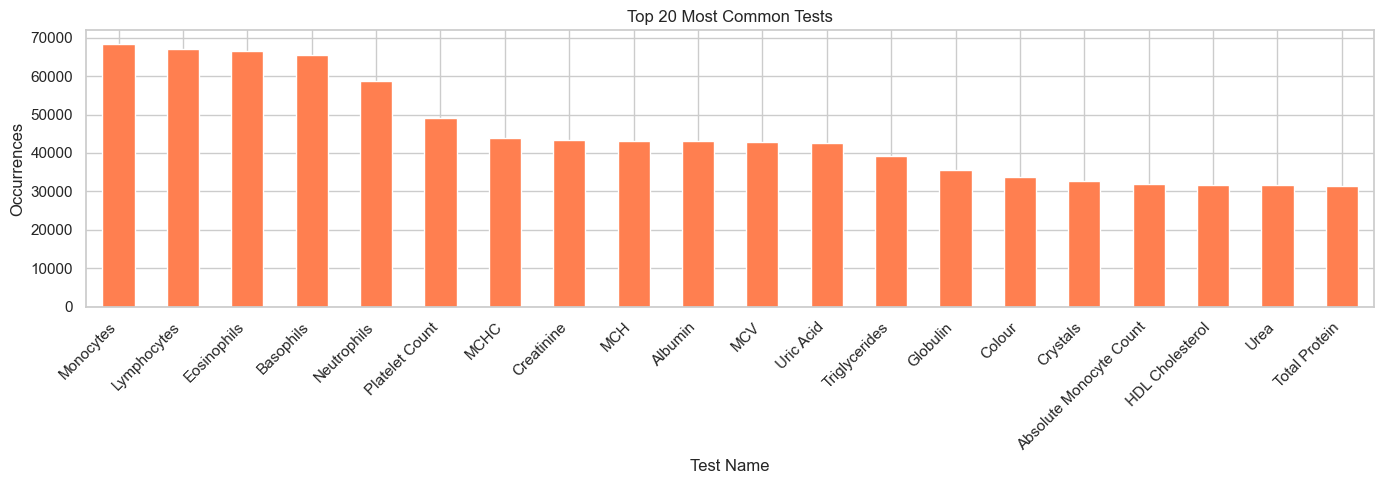

In [10]:
# Which tests appear most frequently across all patients?
top_tests = df["test_name"].value_counts().head(20)

plt.figure(figsize=(14, 5))
top_tests.plot(kind="bar", color="coral", edgecolor="white")
plt.title("Top 20 Most Common Tests")
plt.xlabel("Test Name")
plt.ylabel("Occurrences")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Step 5 — Missing Value Heatmap (Top Tests)
After pivoting to wide format, most cells will be NaN because not every patient  
took every test. This heatmap shows the pattern for the top 30 tests.

Wide format shape (patients × tests): (98256, 30)


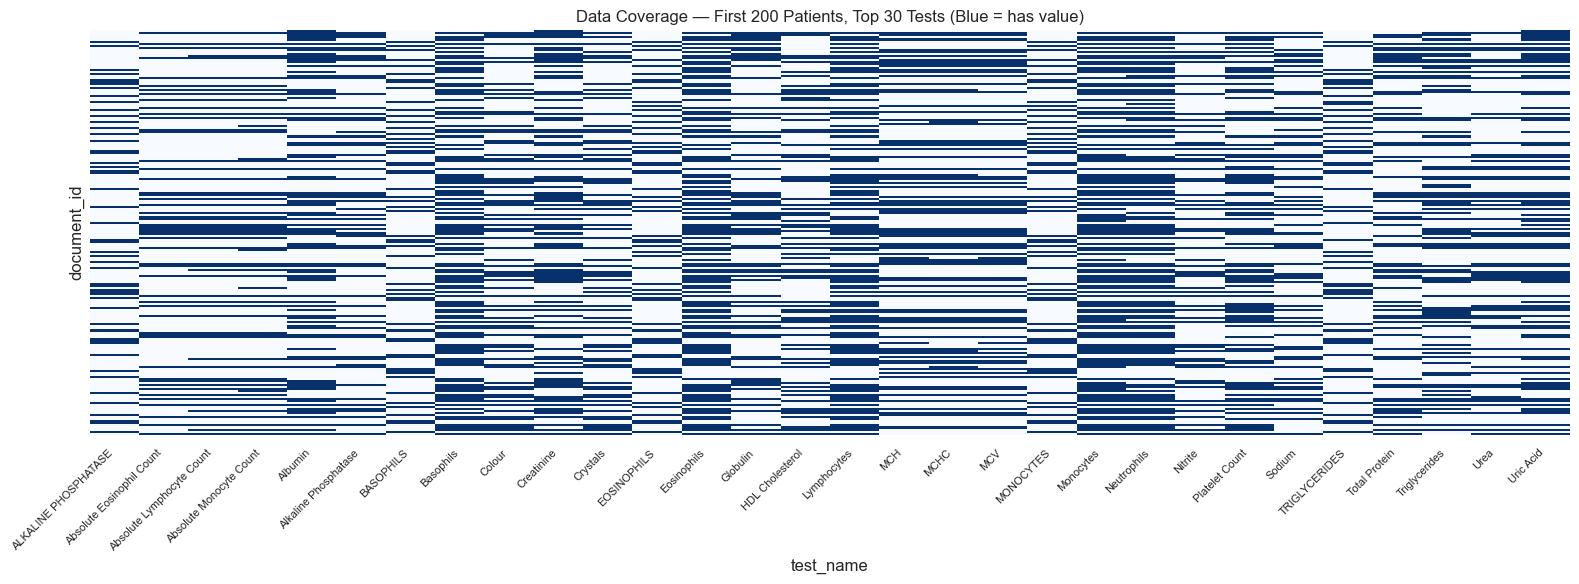

In [11]:
# Pivot a SAMPLE first (full 100k pivot is done in 02_Preprocessing.ipynb)
# Take top 30 tests by frequency
top30 = df["test_name"].value_counts().head(30).index.tolist()
df_top30 = df[df["test_name"].isin(top30)]

# Pivot: rows = patients, cols = test names, values = measured value
sample_wide = df_top30.pivot_table(
    index="document_id",
    columns="test_name",
    values="value",
    aggfunc="first"   # if a patient has duplicates, take the first reading
)

print(f"Wide format shape (patients × tests): {sample_wide.shape}")

# Heatmap: 1 = has value, 0 = missing
plt.figure(figsize=(16, 6))
sns.heatmap(
    sample_wide.head(200).notna(),   # show first 200 patients
    cmap="Blues",
    cbar=False,
    xticklabels=True,
    yticklabels=False
)
plt.title("Data Coverage — First 200 Patients, Top 30 Tests (Blue = has value)")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

## Step 6 — Exploring `display_ranges` (Indian Lab Reference Ranges)
This column is what makes NidaanKosha unique — it contains the reference range  
as printed by the Indian diagnostic lab. We'll use this later to derive  
abnormality labels (without needing a separate disease column).

In [12]:
# What does display_ranges look like?
print("Sample display_ranges values:")
print(df["display_ranges"].dropna().head(20).tolist())

# How often is it missing?
missing_pct = df["display_ranges"].isnull().mean() * 100
print(f"\nMissing display_ranges: {missing_pct:.1f}%")

Sample display_ranges values:
['< 34.0', '3.2 - 4.8', '45.0 - 129.0', '< 31.0', '0.0 - 0.9', '< 0.3', '0.3 - 1.2', '< 38.0', '5.7 - 8.2', '0.9 - 2.0', '2.5 - 3.4', '35.0 - 80.0', '1.5 - 3.5', '85.0 - 130.0', '< 160.0', '3.0 - 5.0', '125.0 - 200.0', '25.0 - 200.0', '5.0 - 40.0', '0.3 - 5.5']

Missing display_ranges: 10.9%


In [13]:
# For a specific test (e.g., HbA1c), what ranges do different Indian labs report?
test_of_interest = "HbA1c"   # change this to any test name you want to inspect

ranges_for_test = (
    df[df["test_name"].str.contains(test_of_interest, case=False, na=False)]
    ["display_ranges"]
    .dropna()
    .value_counts()
    .head(10)
)

print(f"Top reference ranges reported for '{test_of_interest}' by Indian labs:")
print(ranges_for_test)

Top reference ranges reported for 'HbA1c' by Indian labs:
display_ranges
4.0 - 5.6                                                                                                        7423
< 5.7                                                                                                            6208
impaired glucose tolerance:\n5.7-6.4\ndiabetes: > 6.5\nnon diabetic level: < 5.70                                5072
above 6.5 diabetes\nimpaired glucose tolerance:\n5.7-6.4\nbelow 5.6 non diabetic level                           1872
impaired glucose tolerance: 5.7\n6.4\ndiabetes: > 6.5\nnon diabetic level: < 5.70                                1542
non-diabetic: <= 5.6\npre-diabetic: 5.7-6.4\ndiabetic: >= 6.5                                                    1470
2.0 - 5.6                                                                                                        1417
non-diabetic: <= 5.6\npre-diabetic: 5.7-6.4\ndiabetic: >= 6.5\namerican diabetes association\nguideli

## EDA Summary & Next Steps
- **Shape confirmed** — long format with millions of rows ✓  
- **Demographics** — age/gender distributions checked ✓  
- **Coverage** — avg tests per patient understood ✓  
- **display_ranges** — Indian lab ranges explored ✓  

**Next notebook → `02_Preprocessing.ipynb`**  
Full long → wide pivot, LOINC-based column standardization, normalization.